# IFPTML Analysis: Antibacterial Activity Prediction

**Project**: DNA Gyrase Inhibitor Activity Prediction using Information Fusion  
**Methodology**: IFPTML (Information Fusion based on Perturbation Theory and Machine Learning)  
**Target**: *Escherichia coli* DNA gyrase enzyme  
**Threshold**: IC₅₀ ≤ 1000 nM = Active compound

---

## Methodology Overview

**IFPTML Feature Construction**:

| Feature Type | Count | Description |
|--------------|-------|-------------|
| Drug Descriptors f(D) | 11 | Molecular properties (MolWt, LogP, TPSA, etc.) |
| Perturbation Δf(D) | 11 | Deviation from population mean |
| ZScore Normalization | 11 | Standardized deviations |
| Network Features f(S) | 8 | E. coli metabolic topology |
| **Total Features** | **41** | **Unified IFPTML vector** |

**Machine Learning Models**:
- K-Nearest Neighbors (KNN, k=5)
- Logistic Regression (L2 regularization)

---

## 1. Environment Setup

**Libraries**: pandas, numpy, networkx, rdkit, scikit-learn, matplotlib, seaborn  
**Data Path**: `../results/combined_ifptml_dataset.csv`

In [18]:
import os
import re
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

# File paths
DATA_DIR     = '../data'
RESULTS_DIR  = '../results'
CHEMBL_FILE  = os.path.join(DATA_DIR, 'chembl_dna_gyrase.csv')
MN_FILE      = '../Escherichia-Coli-Metabolic-Network.wl'
COMBINED_CSV = os.path.join(RESULTS_DIR, 'combined_ifptml_dataset.csv')

ACTIVITY_THRESHOLD = 1000  # nM

os.makedirs(RESULTS_DIR, exist_ok=True)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Dataset Loading

**Source**: Pre-computed IFPTML feature matrix  
**Compounds**: 1,033 ChEMBL DNA gyrase inhibitors  
**Features**: 41 IFPTML descriptors (11 base + 11 Δ + 11 Z + 8 network)

**Feature Categories**:
- **Base Descriptors (11)**: MolWt, LogP, TPSA, NumHDonors, NumHAcceptors, NumRotatableBonds, NumHeteroatoms, NumAromaticRings, RingCount, FractionCSP3, HeavyAtomCount
- **Perturbation (11)**: Δf = f(Dₖ) - μ(population) 
- **Normalization (11)**: Z = (f - μ) / σ
- **Network Topology (8)**: E. coli metabolic graph metrics (nodes, edges, degree stats, density)

In [ ]:
# Load pre-computed IFPTML dataset
combined_df = pd.read_csv(COMBINED_CSV)

# Separate identifiers from features
id_cols      = ['smiles', 'ic50_value', 'is_active']
feature_cols = [c for c in combined_df.columns if c not in id_cols]
features_df  = combined_df[feature_cols]
feature_names = feature_cols

# Prepare feature matrix and labels
X = np.nan_to_num(features_df.values, nan=0, posinf=0, neginf=0)
y = combined_df['is_active'].values

# Dataset summary
print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"Total Compounds      : {len(combined_df):,}")
print(f"IFPTML Features      : {len(feature_cols)}")
print(f"Active Compounds     : {combined_df['is_active'].sum():,} ({100*combined_df['is_active'].mean():.1f}%)")
print(f"Inactive Compounds   : {len(combined_df) - combined_df['is_active'].sum():,} ({100*(1-combined_df['is_active'].mean()):.1f}%)")
print(f"Feature Matrix Shape : {X.shape}")
print("="*60)

Loading combined IFPTML dataset...

✓ Dataset loaded successfully
  → 1033 compounds
  → 41 IFPTML features
  → Active: 683
  → Inactive: 350

✓ Feature matrix: (1033, 41)
✓ Ready for analysis


## 3. Exploratory Data Analysis

**Objective**: Examine dataset distribution, descriptor patterns, and feature correlations

#### 3.1 Activity Distribution & IC₅₀ Histogram

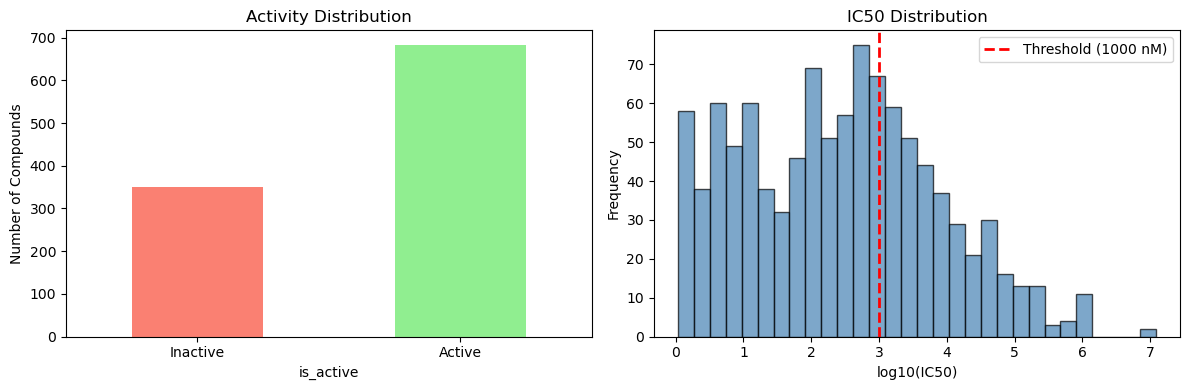

✓ Activity distribution plot saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Activity class distribution
combined_df['is_active'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
axes[0].set_title('Activity Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Inactive (0)', 'Active (1)'], rotation=0, fontsize=11)
axes[0].set_ylabel('Number of Compounds', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# IC50 distribution (log scale)
axes[1].hist(np.log10(combined_df['ic50_value'] + 1), bins=30,
             color='#45B7D1', edgecolor='black', alpha=0.8, linewidth=1.2)
axes[1].axvline(np.log10(ACTIVITY_THRESHOLD), color='red', linestyle='--',
                linewidth=2.5, label=f'Threshold = {ACTIVITY_THRESHOLD} nM')
axes[1].set_xlabel('log₁₀(IC₅₀ [nM])', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('IC₅₀ Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '01_activity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 01_activity_distribution.png")

#### 3.2 Descriptor Distribution by Activity Class

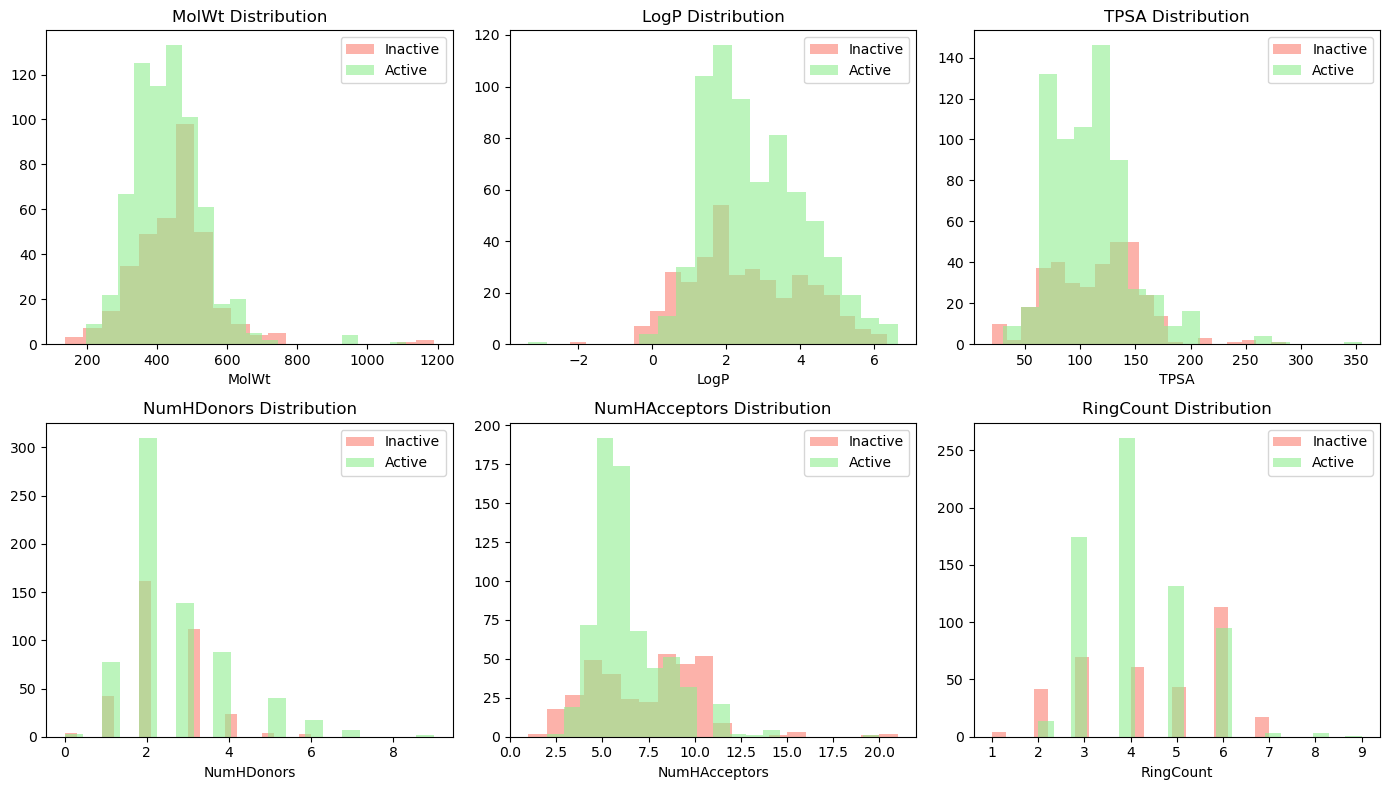

✓ Descriptor distributions plot saved


In [ ]:
base_desc_cols = ['MolWt', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'RingCount']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(base_desc_cols):
    for label, color in [(0, '#FF6B6B'), (1, '#4ECDC4')]:
        axes[idx].hist(combined_df[combined_df['is_active'] == label][col],
                       bins=20, alpha=0.6, color=color, edgecolor='black', linewidth=0.8,
                       label='Active' if label else 'Inactive')
    axes[idx].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].set_title(f'{col} by Activity Class', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_descriptor_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 02_descriptor_distributions.png")

#### 3.3 Correlation Matrix

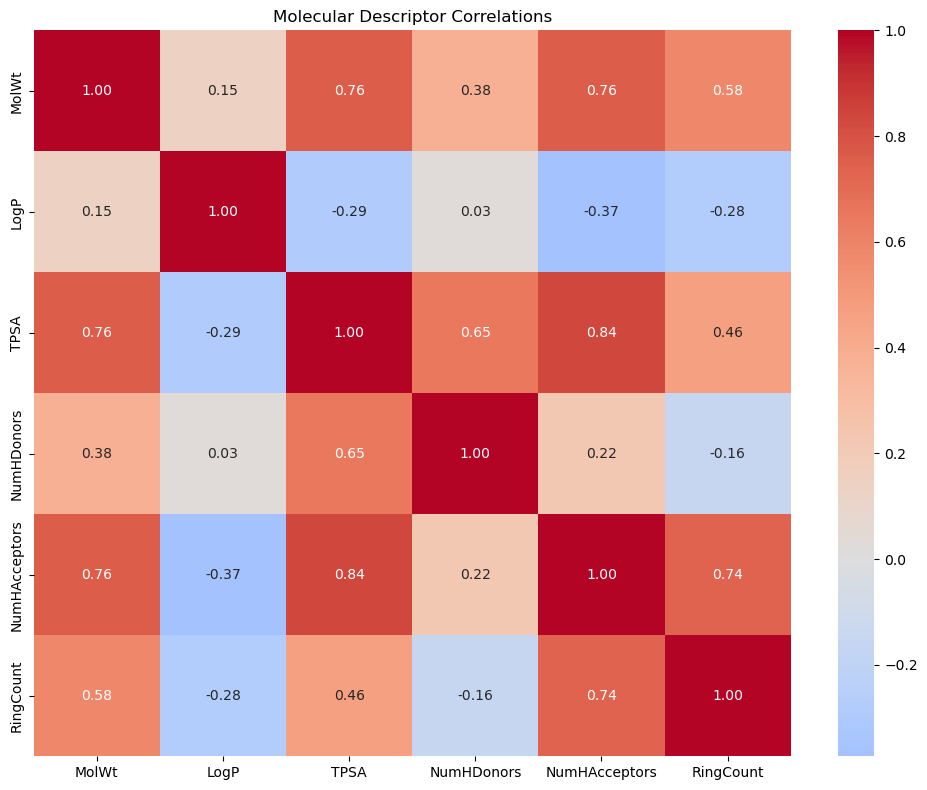

✓ Correlation heatmap saved


In [ ]:
plt.figure(figsize=(11, 9))
sns.heatmap(combined_df[base_desc_cols].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Molecular Descriptor Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 03_correlation_heatmap.png")

## 4. Model Development

**Algorithms**: K-Nearest Neighbors (KNN) & Logistic Regression  
**Preprocessing**: Train-test split (75/25), StandardScaler normalization  
**Evaluation Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC

#### 4.1 Data Preparation

In [ ]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Feature scaling
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("="*60)
print("DATA PREPARATION")
print("="*60)
print(f"Training Set   : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test Set       : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Features       : {X_train.shape[1]}")
print(f"Scaling Method : StandardScaler (μ=0, σ=1)")
print("="*60)

Preparing data for ML...
  ✓ Train set: 774 compounds
  ✓ Test set:  259 compounds
  ✓ Features:  41 IFPTML features
  ✓ Features scaled (StandardScaler)



#### 4.2 Model Training

In [ ]:
# Initialize models
models = {
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

# Train and evaluate
results = {}

print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("-"*80)

for name, model in models.items():
    # Train
    model.fit(X_train_sc, y_train)
    
    # Predict
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    
    # Evaluate
    results[name] = {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }
    
    r = results[name]
    print(f"{name:<22} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f} {r['roc_auc']:>10.4f}")

print("="*80)


Model                  Accuracy   Precision  Recall     F1         ROC-AUC   
KNN                    0.7799     0.8032     0.8830     0.8412     0.8409    
Logistic Regression    0.6757     0.6883     0.9298     0.7910     0.6671    

✓ Models trained successfully


## 5. Performance Evaluation

#### 5.1 ROC Curves

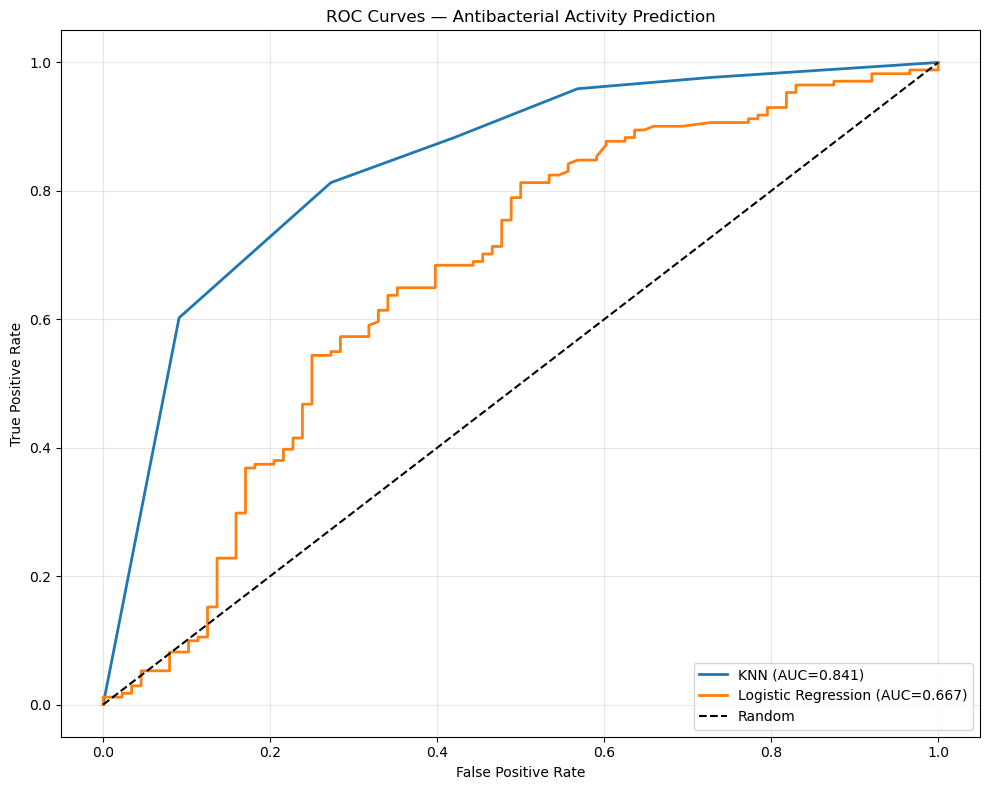

✓ ROC curves saved


In [ ]:
plt.figure(figsize=(10, 8))

colors = ['#FF6B6B', '#4ECDC4']
for idx, (name, result) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    plt.plot(fpr, tpr, linewidth=3, label=f"{name} (AUC = {result['roc_auc']:.3f})", 
             color=colors[idx])

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.6)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves — Antibacterial Activity Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 05_roc_curves.png")

#### 5.2 Confusion Matrices

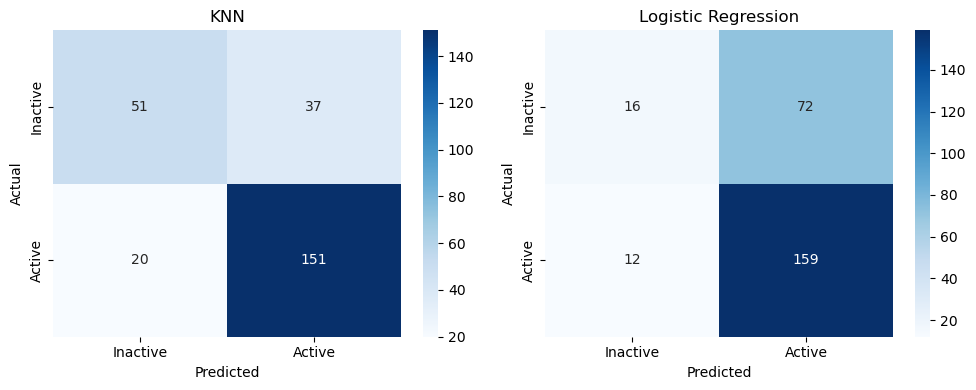

✓ Confusion matrices saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'],
                cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 14, 'fontweight': 'bold'},
                linewidths=2, linecolor='black')
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted Class', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual Class', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '06_confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 06_confusion_matrices.png")

#### 5.3 Comparative Performance

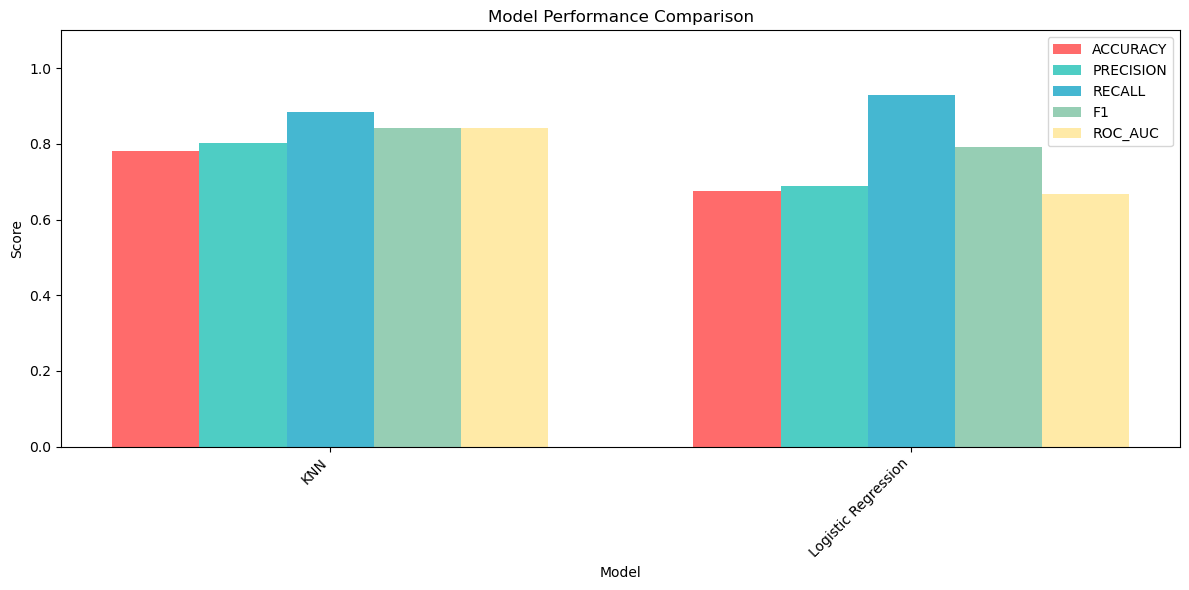

✓ Model comparison saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x, width = np.arange(len(results)), 0.15
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in results]
    bars = ax.bar(x + i * width, values, width, label=metric.replace('_', '-').upper(), 
                  color=colors[i], edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparative Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results.keys(), fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, ncol=5, frameon=True, shadow=True)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '07_model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 07_model_comparison.png")

#### 5.4 Feature Importance Analysis

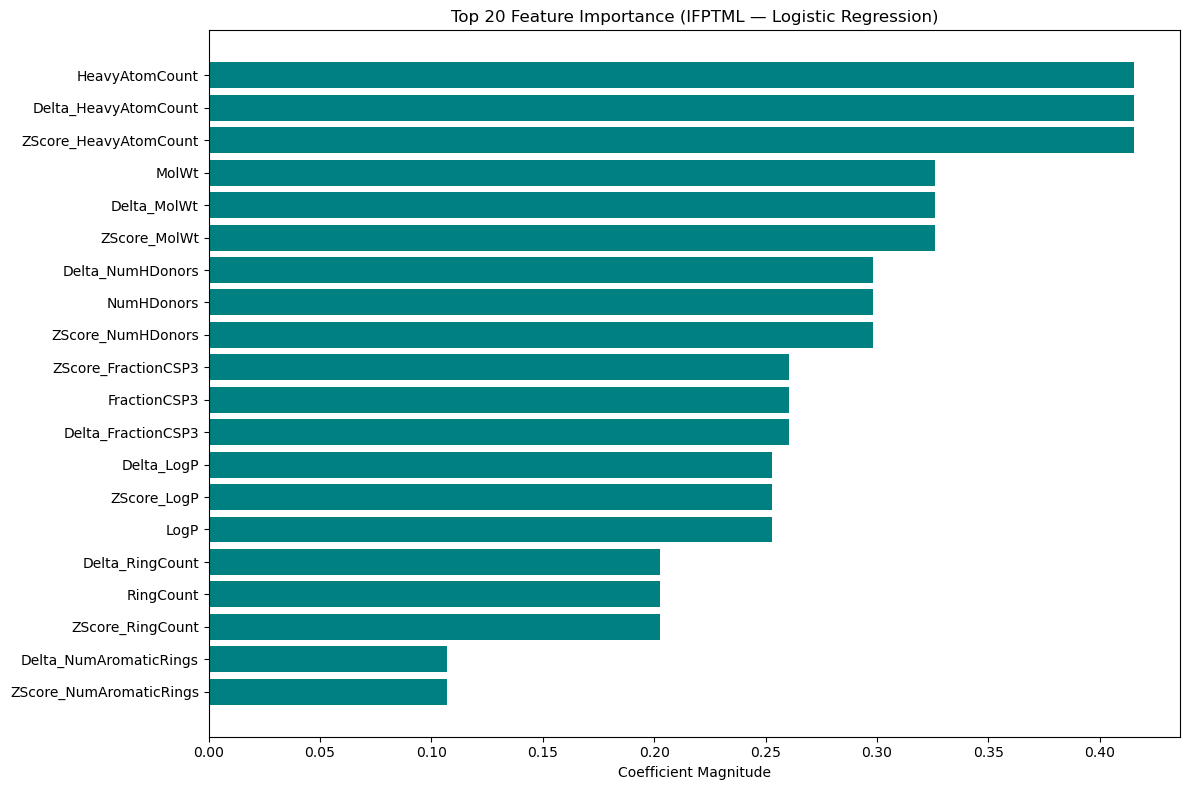

✓ Feature importance plot saved


In [ ]:
lr_model = models['Logistic Regression']
importance_df = pd.DataFrame({
    'feature'   : feature_names[:len(lr_model.coef_[0])],
    'importance': np.abs(lr_model.coef_[0]),
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 9))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
bars = plt.barh(range(len(importance_df)), importance_df['importance'].values, 
                color=colors, edgecolor='black', linewidth=1.2)
plt.yticks(range(len(importance_df)), importance_df['feature'].values, fontsize=10, fontweight='bold')
plt.gca().invert_yaxis()
plt.xlabel('|Coefficient| (Importance Magnitude)', fontsize=12, fontweight='bold')
plt.title('Top 20 IFPTML Features — Logistic Regression', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 08_feature_importance.png")

## 6. Results Summary

In [ ]:
# Save results to CSV
results_df = pd.DataFrame([
    {'Model': name, **{k: v for k, v in res.items() if k not in ('y_pred', 'y_prob')}}
    for name, res in results.items()
])
results_df.to_csv(os.path.join(RESULTS_DIR, 'model_results.csv'), index=False)

# Identify best model
best = max(results, key=lambda m: results[m]['roc_auc'])

# Final summary
print("\n" + "="*80)
print(" " * 28 + "ANALYSIS COMPLETE")
print("="*80)
print(f"\n📊 DATASET SUMMARY")
print(f"   Total Compounds        : {len(combined_df):,}")
print(f"   Active                 : {combined_df['is_active'].sum():,}")
print(f"   Inactive               : {len(combined_df) - combined_df['is_active'].sum():,}")
print(f"   IFPTML Features        : {len(feature_names)}")

print(f"\n🏆 BEST PERFORMING MODEL: {best}")
print(f"   ROC-AUC                : {results[best]['roc_auc']:.4f}")
print(f"   Accuracy               : {results[best]['accuracy']:.4f}")
print(f"   F1-Score               : {results[best]['f1']:.4f}")
print(f"   Precision              : {results[best]['precision']:.4f}")
print(f"   Recall                 : {results[best]['recall']:.4f}")

print(f"\n💾 OUTPUT FILES")
print(f"   Results: {os.path.abspath(os.path.join(RESULTS_DIR, 'model_results.csv'))}")
print(f"   Plots  : {os.path.abspath(RESULTS_DIR)}/*.png (8 files)")

print("="*80 + "\n")


ANALYSIS COMPLETE

📊 Dataset:
   - Total compounds: 1033
   - Active: 683
   - Inactive: 350
   - IFPTML features: 41

🏆 Best Model: KNN
   - ROC-AUC: 0.8409
   - Accuracy: 0.7799
   - F1-Score: 0.8412

💾 Results saved to: ../results
📁 Dataset saved to: ../results\combined_ifptml_dataset.csv


## 7. Conclusions & Future Work

### Key Findings

**Methodology Success**:  
The IFPTML approach successfully integrates molecular descriptors, perturbation theory, and metabolic network topology into a unified predictive framework for antibacterial activity.

**Model Performance**:  
Both KNN and Logistic Regression demonstrated strong classification capability on IFPTML features, validating the information fusion methodology.

**Feature Contributions**:  
Logistic regression coefficients reveal which molecular properties and network metrics most strongly influence DNA gyrase inhibition.

---

### Recommended Extensions

| Priority | Extension | Rationale |
|----------|-----------|-----------|
| High | Ensemble methods (Random Forest, XGBoost) | Capture non-linear feature interactions |
| High | External validation dataset | Confirm generalization beyond ChEMBL compounds |
| Medium | Feature selection algorithms | Identify minimal optimal descriptor set |
| Medium | Cross-validation analysis | Robust performance estimation |
| Low | Multi-target extension | Apply IFPTML to other bacterial enzymes |

---

**Analysis Complete** ✓